## Flu Forecasting (FluSight Evaluation)

### Background

This project investigates whether a deep learning model can improve short-term forecasting of weekly U.S. influenza hospital admissions, with particular focus on the rapid-onset and turning-point periods where existing approaches are weakest. 

The goal is to develop a model that can accurately predict the number of influenza hospital admissions in the U.S. for the next 1-4 weeks, using historical data and other relevant features.

However, the initial prediction will be for the next 1 week, and the model will be evaluated based on its performance in predicting the number of admissions for that week. The model's performance will be compared to existing models and benchmarks, such as the FluSight challenge.

### Data Sources

The data to be used in this project is pulled from CDC NHSN (National Healthcare Safety Network) lab-confirmed hospitalization data from February 2022 to June 2026 with 52 states and the earlier FluSight incident hospitalization data frm 2020 to 2023. This is combined into 338 weekly national observations.

#### 1. CDC NHSN Data

In [ ]:
# Installs

!pip install scikit-learn joblib numpy pandas matplotlib scipy

In [145]:
# Load the libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

In [146]:
# Source 1: Older FluSight incident hospitalization series

inc = pd.read_csv("data/incident_hosp.csv", parse_dates=["date"])
print("Incident hosp shape:", inc.shape)
print("Date range:", inc["date"].min().date(), "to", inc["date"].max().date())

Incident hosp shape: (10442, 4)
Date range: 2020-01-11 to 2023-11-11


In [147]:
print(inc.head())

        date location location_name  value
0 2020-01-11       01       Alabama      0
1 2020-01-11       15        Hawaii      0
2 2020-01-11       18       Indiana      0
3 2020-01-11       27     Minnesota      0
4 2020-01-11       30       Montana      0


In [148]:
# Source 2: NHSN hospitalization series (2022-2026)
hosp = pd.read_csv("data/hosp_admissions.csv", parse_dates=["date"])
print("NHSN hosp shape:", hosp.shape)
print("Date range:", hosp["date"].min().date(), "to", hosp["date"].max().date())
print(hosp.head())

NHSN hosp shape: (12190, 5)
Date range: 2022-02-05 to 2026-06-27
        date location location_name  value  weekly_rate
0 2026-06-27       20        Kansas    1.0     0.033663
1 2026-06-27       55     Wisconsin    3.0     0.050327
2 2026-06-27       50       Vermont    0.0     0.000000
3 2026-06-27       18       Indiana    7.0     0.101094
4 2026-06-27       38  North Dakota    3.0     0.376616


In [149]:
# Source 1: filter to US only

us_inc = inc[inc["location"] == "US"][["date", "value"]].copy()
us_inc.columns = ["date", "weekly_admissions"]
us_inc = us_inc.sort_values("date").reset_index(drop=True)
print("Incident hosp (US only):", us_inc.shape)
print(us_inc.tail(5))

Incident hosp (US only): (201, 2)
          date  weekly_admissions
196 2023-10-14               1230
197 2023-10-21               1495
198 2023-10-28               1633
199 2023-11-04               2088
200 2023-11-11               2857


In [150]:
# Source 2: filter to US only, keep weekly_rate as extra column
us_hosp = hosp[hosp["location"] == "US"][["date", "value", "weekly_rate"]].copy()
us_hosp.columns = ["date", "weekly_admissions", "weekly_rate_per100k"]
us_hosp = us_hosp.sort_values("date").reset_index(drop=True)
print("NHSN hosp (US only):", us_hosp.shape)
print(us_hosp.head(5))

NHSN hosp (US only): (230, 3)
        date  weekly_admissions  weekly_rate_per100k
0 2022-02-05             1089.0             0.320190
1 2022-02-12             1161.0             0.341359
2 2022-02-19             1497.0             0.440150
3 2022-02-26             1607.0             0.472493
4 2022-03-05             1792.0             0.526887


In [151]:
# Checking the overlap between the two sources

overlap_start = us_hosp["date"].min()
overlap_end = us_inc["date"].max()

print(f"NHSN starts: {overlap_start.date()}")
print(f"Incident hosp ends: {overlap_end.date()}")

NHSN starts: 2022-02-05
Incident hosp ends: 2023-11-11


In [152]:
# Show both series in the overlap window side by side
overlap_inc = us_inc[us_inc["date"] >= overlap_start][["date", "weekly_admissions"]]
overlap_hosp = us_hosp[us_hosp["date"] <= overlap_end][["date", "weekly_admissions"]]

overlap_check = pd.merge(
    overlap_inc, overlap_hosp, on="date", suffixes=("_incident", "_nhsn")
)
print(f"\nOverlapping weeks: {len(overlap_check)}")
print(overlap_check)


Overlapping weeks: 93
         date  weekly_admissions_incident  weekly_admissions_nhsn
0  2022-02-05                        1137                  1089.0
1  2022-02-12                        1256                  1161.0
2  2022-02-19                        1573                  1497.0
3  2022-02-26                        1666                  1607.0
4  2022-03-05                        1942                  1792.0
..        ...                         ...                     ...
88 2023-10-14                        1230                  1219.0
89 2023-10-21                        1495                  1468.0
90 2023-10-28                        1633                  1618.0
91 2023-11-04                        2088                  2022.0
92 2023-11-11                        2857                  2786.0

[93 rows x 3 columns]


We use incident hosp for everything before Feb 2022 (NHSN start), then switch to NHSN from that point forward. 

In [153]:
cutoff = pd.Timestamp("2022-02-05")  # First date in NHSN series

# Take early period from incident hosp
early = us_inc[us_inc["date"] < cutoff].copy()
early["weekly_rate_per100k"] = None  # NHSN-era column not available here

# Take full NHSN series from cutoff onward
late = us_hosp.copy()

# Concatenate and deduplicate on date
combined = pd.concat([early, late], ignore_index=True)
combined = combined.drop_duplicates(subset="date")
combined = combined.sort_values("date").reset_index(drop=True)

print("Combined shape:", combined.shape)
print("Date range:", combined["date"].min().date(), "to", combined["date"].max().date())
print(combined.head(5))
print(combined.tail(5))

Combined shape: (338, 3)
Date range: 2020-01-11 to 2026-06-27
        date  weekly_admissions weekly_rate_per100k
0 2020-01-11                1.0                None
1 2020-01-18                0.0                None
2 2020-01-25                0.0                None
3 2020-02-01                0.0                None
4 2020-02-08                0.0                None
          date  weekly_admissions weekly_rate_per100k
333 2026-05-30             1063.0            0.312545
334 2026-06-06             1017.0             0.29902
335 2026-06-13              850.0            0.249918
336 2026-06-20              764.0            0.224633
337 2026-06-27              729.0            0.214342


In [154]:
# Show rows just before and after the cutoff
seam_window = combined[combined["date"].between("2022-01-01", "2022-03-01")]
print("Rows around the merge seam:")
print(seam_window[["date", "weekly_admissions", "weekly_rate_per100k"]])

Rows around the merge seam:
          date  weekly_admissions weekly_rate_per100k
103 2022-01-01             2771.0                None
104 2022-01-08             1992.0                None
105 2022-01-15             1651.0                None
106 2022-01-22             1134.0                None
107 2022-01-29              950.0                None
108 2022-02-05             1089.0             0.32019
109 2022-02-12             1161.0            0.341359
110 2022-02-19             1497.0             0.44015
111 2022-02-26             1607.0            0.472493


In [155]:
# Confirm no duplicate dates introduced
assert combined["date"].nunique() == len(combined), "Duplicate dates found!"
print("No duplicate dates — merge is clean.")

# Confirm no missing weeks
combined["gap_days"] = combined["date"].diff().dt.days
bad_gaps = combined[combined["gap_days"] != 7]
print(f"Weeks with gap != 7 days: {len(bad_gaps) - 1}")  # -1 for first row NaN

No duplicate dates — merge is clean.
Weeks with gap != 7 days: 0


In [156]:
# Drop the diagnostic column before saving
combined = combined.drop(columns=["gap_days"])

print(combined.dtypes)
print(combined.shape)

date                   datetime64[us]
weekly_admissions             float64
weekly_rate_per100k            object
dtype: object
(338, 3)


In [157]:
combined.to_csv("data/combined_flu_us.csv", index=False)

print("Saved: combined_flu_us.csv")

Saved: combined_flu_us.csv


In [158]:
state_hosp = hosp[hosp["location"] != "US"].copy()

print(f"State rows : {state_hosp.shape[0]}")
print(f"States/territories: {state_hosp['location_name'].nunique()}")

State rows : 11960
States/territories: 52


In [159]:
# Save separately
state_hosp.to_csv("data/state_hosp.csv", index=False)
print("Saved: state_hosp.csv")

Saved: state_hosp.csv


In [160]:
# Load the data

df = pd.read_csv("data/combined_flu_us.csv", parse_dates=["date"])

df.head()

,date,weekly_admissions,weekly_rate_per100k
0,2020-01-11,1.0,NaN
1,2020-01-18,0.0,NaN
2,2020-01-25,0.0,NaN
3,2020-02-01,0.0,NaN
4,2020-02-08,0.0,NaN


#### 2. Google Trends Data - Flu

Ten search terms were initially considered as exogenous features: `flu`, `flu symptoms`, `flu medicine`, `flu treatment`, `influenza`, `do I have the flu`, `flu season`, `fever`, `cough remedy`, and `sore throat remedy`. 

Following inspection of the downloaded data, five terms were removed prior to feature construction. `Flu medicine`, `flu treatment`, `do I have the flu`, and `cough remedy` returned near-zero values throughout the entire period and carry no discriminating signal. `Fever` was removed because its search volume peaks in summer months as June and September 2024 reached index values of 94, reflecting general heat-related illness rather than influenza activity, and including it would introduce noise inversely correlated with the flu season. 

The term `flu season` was dropped due to a download error that returned all-zero values. 

The final composite search index is constructed from four terms: `flu`, `flu symptoms`, `influenza`, and `sore throat`, all of which show clear seasonal alignment with peak hospitalization months.

In [161]:
trends_raw = pd.read_csv("data/google_trends.csv", skiprows=0)

print(trends_raw.head())

         Time  flu  flu symptoms  influenza  flue season  sore throat
0  2022-10-01   56             6          3            0           17
1  2022-11-01   73            13          8            0           21
2  2022-12-01   75            13         10            0           22
3  2023-01-01   30             5          3            0           18
4  2023-02-01   22             4          3            0           17


In [162]:
trends_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Time          45 non-null     str  
 1   flu           45 non-null     int64
 2   flu symptoms  45 non-null     int64
 3   influenza     45 non-null     int64
 4   flue season   45 non-null     int64
 5   sore throat   45 non-null     int64
dtypes: int64(5), str(1)
memory usage: 2.2 KB


In [163]:
trends_raw = trends_raw.rename(columns={"Time": "date"})
trends_raw["date"] = pd.to_datetime(trends_raw["date"])

# Drop the zero-value flue season column
trends_raw = trends_raw.drop(columns=["flue season"])

print("Trends shape:", trends_raw.shape)

print("Columns:", trends_raw.columns.tolist())
print(
    "Date range:",
    trends_raw["date"].min().date(),
    "to",
    trends_raw["date"].max().date(),
)

Trends shape: (45, 5)
Columns: ['date', 'flu', 'flu symptoms', 'influenza', 'sore throat']
Date range: 2022-10-01 to 2026-06-01


In [164]:
# Build composite search index from four valid terms
search_terms = ["flu", "flu symptoms", "influenza", "sore throat"]
trends_raw["flu_search_index"] = trends_raw[search_terms].mean(axis=1)

print("Search index stats:")
print(trends_raw["flu_search_index"].describe().round(3))

Search index stats:
count    45.000
mean     14.250
std       7.699
min       5.500
25%       8.250
50%      12.000
75%      17.000
max      36.000
Name: flu_search_index, dtype: float64


In [165]:
# Forward-fill monthly to weekly to align with nhsn_active
# Each week in a month receives the same monthly search index value
weekly_dates = pd.DataFrame(
    {"date": pd.date_range(start="2022-10-01", end="2026-06-30", freq="W-SAT")}
)
weekly_dates["month"] = weekly_dates["date"].dt.to_period("M")
trends_raw["month"] = trends_raw["date"].dt.to_period("M")

trends_weekly = pd.merge(
    weekly_dates,
    trends_raw[["month", "flu_search_index"] + search_terms],
    on="month",
    how="left",
).drop(columns=["month"])

print("Weekly trends shape:", trends_weekly.shape)
print(f"Nulls after forward-fill: {trends_weekly['flu_search_index'].isna().sum()}")
print(trends_weekly.head(10))

Weekly trends shape: (196, 6)
Nulls after forward-fill: 0
        date  flu_search_index  flu  flu symptoms  influenza  sore throat
0 2022-10-01             20.50   56             6          3           17
1 2022-10-08             20.50   56             6          3           17
2 2022-10-15             20.50   56             6          3           17
3 2022-10-22             20.50   56             6          3           17
4 2022-10-29             20.50   56             6          3           17
5 2022-11-05             28.75   73            13          8           21
6 2022-11-12             28.75   73            13          8           21
7 2022-11-19             28.75   73            13          8           21
8 2022-11-26             28.75   73            13          8           21
9 2022-12-03             30.00   75            13         10           22


In [166]:
# Confirm weekly count is correct after merge

print(f"trends_weekly rows: {len(trends_weekly)}")

trends_weekly rows: 196


In [167]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date                 338 non-null    datetime64[us]
 1   weekly_admissions    338 non-null    float64       
 2   weekly_rate_per100k  230 non-null    float64       
dtypes: datetime64[us](1), float64(2)
memory usage: 8.1 KB


In [168]:
df = df.sort_values("date").reset_index(drop=True)

In [169]:
# Checking for missing weeks, all gaps should be 7 days

df["gap_days"] = df["date"].diff().dt.days
missing_weeks = df[df["gap_days"] != 7]

print(f"Rows with gap not equal to 7 days: {len(missing_weeks) - 1}")

Rows with gap not equal to 7 days: 0


In [170]:
# Checking for nulls and zeros

df["weekly_admissions"].isna().sum()

np.int64(0)

In [171]:
# Checking for nulls and zeros

(df["weekly_admissions"] == 0).sum()

np.int64(39)

In [172]:
print(df[df["weekly_admissions"] == 0][["date", "weekly_admissions"]])

         date  weekly_admissions
1  2020-01-18                0.0
2  2020-01-25                0.0
3  2020-02-01                0.0
4  2020-02-08                0.0
5  2020-02-15                0.0
6  2020-02-22                0.0
7  2020-02-29                0.0
8  2020-03-07                0.0
9  2020-03-14                0.0
10 2020-03-21                0.0
11 2020-03-28                0.0
12 2020-04-04                0.0
13 2020-04-11                0.0
14 2020-04-18                0.0
15 2020-04-25                0.0
16 2020-05-02                0.0
17 2020-05-09                0.0
18 2020-05-16                0.0
19 2020-05-23                0.0
20 2020-05-30                0.0
21 2020-06-06                0.0
22 2020-06-13                0.0
23 2020-06-20                0.0
24 2020-06-27                0.0
25 2020-07-04                0.0
26 2020-07-11                0.0
27 2020-07-18                0.0
28 2020-07-25                0.0
29 2020-08-01                0.0
30 2020-08

39 zeros exist but all in 2020 which can be attributed to a COVID suppression artifact, not a data error. 

In [173]:
# Inspecting the seam between the two data sources

seam = pd.Timestamp("2022-02-05")

print("Last 4 weeks of incident hosp (pre-NHSN):")
print(df[df["date"] < seam].tail(4)[["date", "weekly_admissions"]])

Last 4 weeks of incident hosp (pre-NHSN):
          date  weekly_admissions
104 2022-01-08             1992.0
105 2022-01-15             1651.0
106 2022-01-22             1134.0
107 2022-01-29              950.0


In [174]:
print("First 4 weeks of NHSN era:")
print(df[df["date"] >= seam].head(4)[["date", "weekly_admissions"]])

First 4 weeks of NHSN era:
          date  weekly_admissions
108 2022-02-05             1089.0
109 2022-02-12             1161.0
110 2022-02-19             1497.0
111 2022-02-26             1607.0


In [175]:
# Statistical outlier checks on NHSN period

nhsn = df[df["date"] >= seam].copy()

nhsn["zscore"] = (nhsn["weekly_admissions"] - nhsn["weekly_admissions"].mean()) / nhsn[
    "weekly_admissions"
].std()

print("Extreme outliers |z| > 3:")
print(nhsn[nhsn["zscore"].abs() > 3][["date", "weekly_admissions", "zscore"]])

Extreme outliers |z| > 3:
          date  weekly_admissions    zscore
260 2025-01-04            39669.0  3.317188
263 2025-01-25            41512.0  3.500051
264 2025-02-01            52705.0  4.610622
265 2025-02-08            55757.0  4.913442
266 2025-02-15            48009.0  4.144684
267 2025-02-22            39463.0  3.296749
311 2025-12-27            37632.0  3.115077
312 2026-01-03            42648.0  3.612765


Typically, any z-score greater than +3 or less than -3 is considered unusually far from the mean and may be flagged as an outlier.

The 2024–25 peak weeks are statistical outliers (z>3) but real events, not errors.

### Distribution of weekly admissions

In [176]:
nhsn = df[df["date"] >= "2022-02-05"].copy()
vals = nhsn["weekly_admissions"].dropna()

# Descriptive statistics
print("Descriptive statistics for NHSN period:")
print(vals.describe())

Descriptive statistics for NHSN period:
count      230.000000
mean      6236.391304
std      10078.598731
min        223.000000
25%        879.500000
50%       1709.000000
75%       6493.000000
max      55757.000000
Name: weekly_admissions, dtype: float64


In [177]:
print(f"Skew: {vals.skew():.3f}")

Skew: 2.609


In [178]:
print(f"Kurtosis: {vals.kurtosis():.3f}")

Kurtosis: 7.135


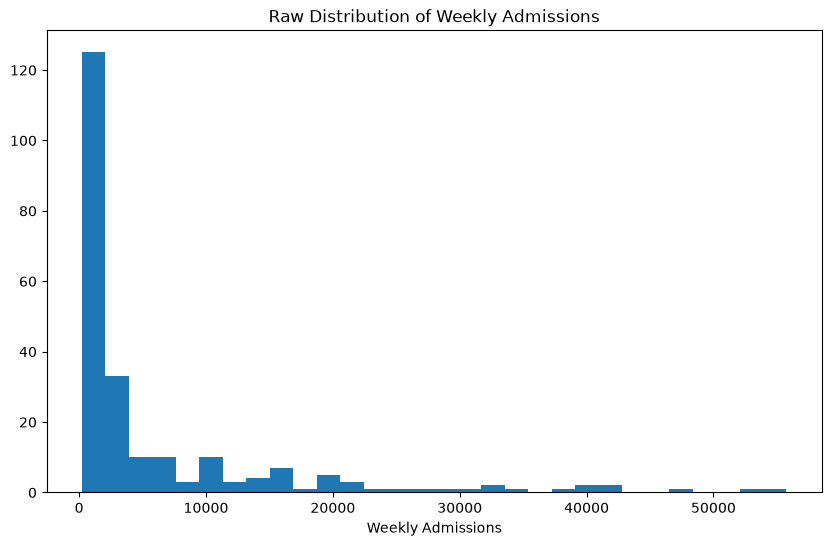

In [179]:
# Visualizing the distribution of weekly admissions during the NHSN period

plt.figure(figsize=(10, 6))

plt.hist(vals, bins=30)
plt.title("Raw Distribution of Weekly Admissions")
plt.xlabel("Weekly Admissions")
plt.show()

The data seems to be right-skewed, with a long tail of higher values. This is consistent with the nature of influenza outbreaks, where most weeks have relatively low admissions, but occasional peaks can be quite high.

We chose to test the log transformation of the weekly admissions to see if it normalizes the distribution and improves model performance.

In [180]:
log_vals = np.log1p(vals)

print(f"Log   — Skew: {log_vals.skew():.3f}, Kurtosis: {log_vals.kurtosis():.3f}")

Log   — Skew: 0.511, Kurtosis: -0.660


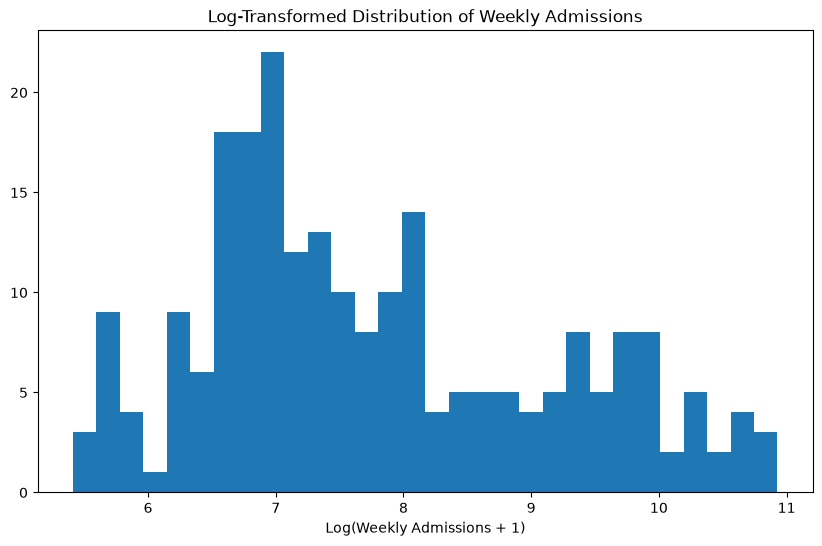

In [181]:
# Visualizing the distribution of weekly admissions during the NHSN period

plt.figure(figsize=(10, 6))

plt.hist(log_vals, bins=30)
plt.title("Log-Transformed Distribution of Weekly Admissions")
plt.xlabel("Log(Weekly Admissions + 1)")
plt.show()

The skew dropped from 2.609 to 0.511 which is much closer to 0, which would be a perfect symmetry. The log transformation successfully compressed the long right tail.

Kurtosis of -0.660 means the distribution is now slightly flat-topped (platykurtic) AS values are more spread evenly across the range rather than clustering sharply. 

In [182]:
# Shapiro-Wilk test for normality on log-transformed data
_, p_raw = stats.shapiro(vals)
_, p_log = stats.shapiro(log_vals)

print(f"Shapiro-Wilk test p-values: Raw: {p_raw:.3f}, Log-transformed: {p_log:.3f}")

Shapiro-Wilk test p-values: Raw: 0.000, Log-transformed: 0.000


Text(0.5, 1.0, 'QQ Plot (log-transformed)')

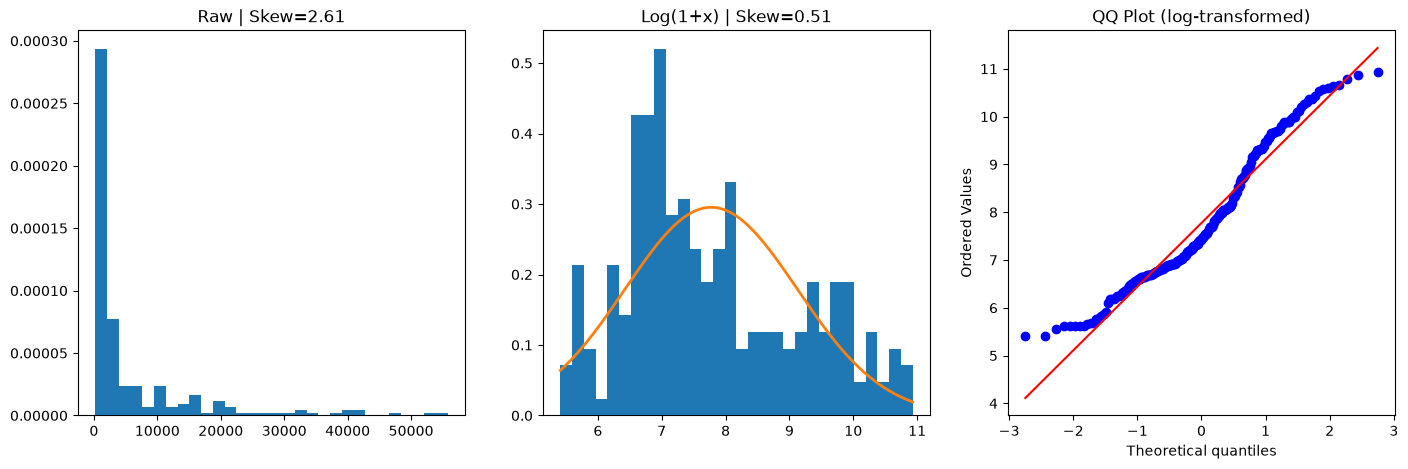

In [183]:
# Plot: raw histogram, log histogram, QQ plot
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].hist(vals, bins=30, density=True)
axes[0].set_title(f"Raw | Skew={vals.skew():.2f}")

axes[1].hist(log_vals, bins=30, density=True)
mu, std = stats.norm.fit(log_vals)
x = np.linspace(log_vals.min(), log_vals.max(), 300)
axes[1].plot(x, stats.norm.pdf(x, mu, std), lw=2)
axes[1].set_title(f"Log(1+x) | Skew={log_vals.skew():.2f}")

stats.probplot(log_vals, plot=axes[2])
axes[2].set_title("QQ Plot (log-transformed)")

### Seasonal Cycle and Season Comparison

We proceed to try to understand which months consistently mark onset, peak and decline, and how much the peak shifts from year to year. 

In [184]:
nhsn = df[df["date"] >= "2022-02-05"].copy()
nhsn["month"] = nhsn["date"].dt.month

In [185]:
# First, we assign flu season which typically runs from October to May, with the peak often occurring in the winter months. We can define a function to assign a season based on the month of the year.


def assign_season(d):
    return (
        f"{d.year}-{str(d.year+1)[2:]}"
        if d.month >= 10
        else f"{d.year-1}-{str(d.year)[2:]}"
    )


nhsn["season"] = nhsn["date"].apply(assign_season)

In [186]:
for season in nhsn["season"].unique():
    mask = nhsn["season"] == season
    nhsn.loc[mask, "week_of_season"] = range(mask.sum())

active_months = [10, 11, 12, 1, 2, 3, 4, 5]
complete_seasons = ["2022-23", "2023-24", "2024-25", "2025-26"]
nhsn_active = nhsn[
    nhsn["date"].dt.month.isin(active_months) & nhsn["season"].isin(complete_seasons)
].copy()

In [187]:
# Recompute week_of_season on the filtered active data
for season in nhsn_active["season"].unique():
    mask = nhsn_active["season"] == season
    nhsn_active.loc[mask, "week_of_season"] = range(mask.sum())

print(nhsn_active.groupby("season")["week_of_season"].max())

season
2022-23    34.0
2023-24    33.0
2024-25    34.0
2025-26    34.0
Name: week_of_season, dtype: float64


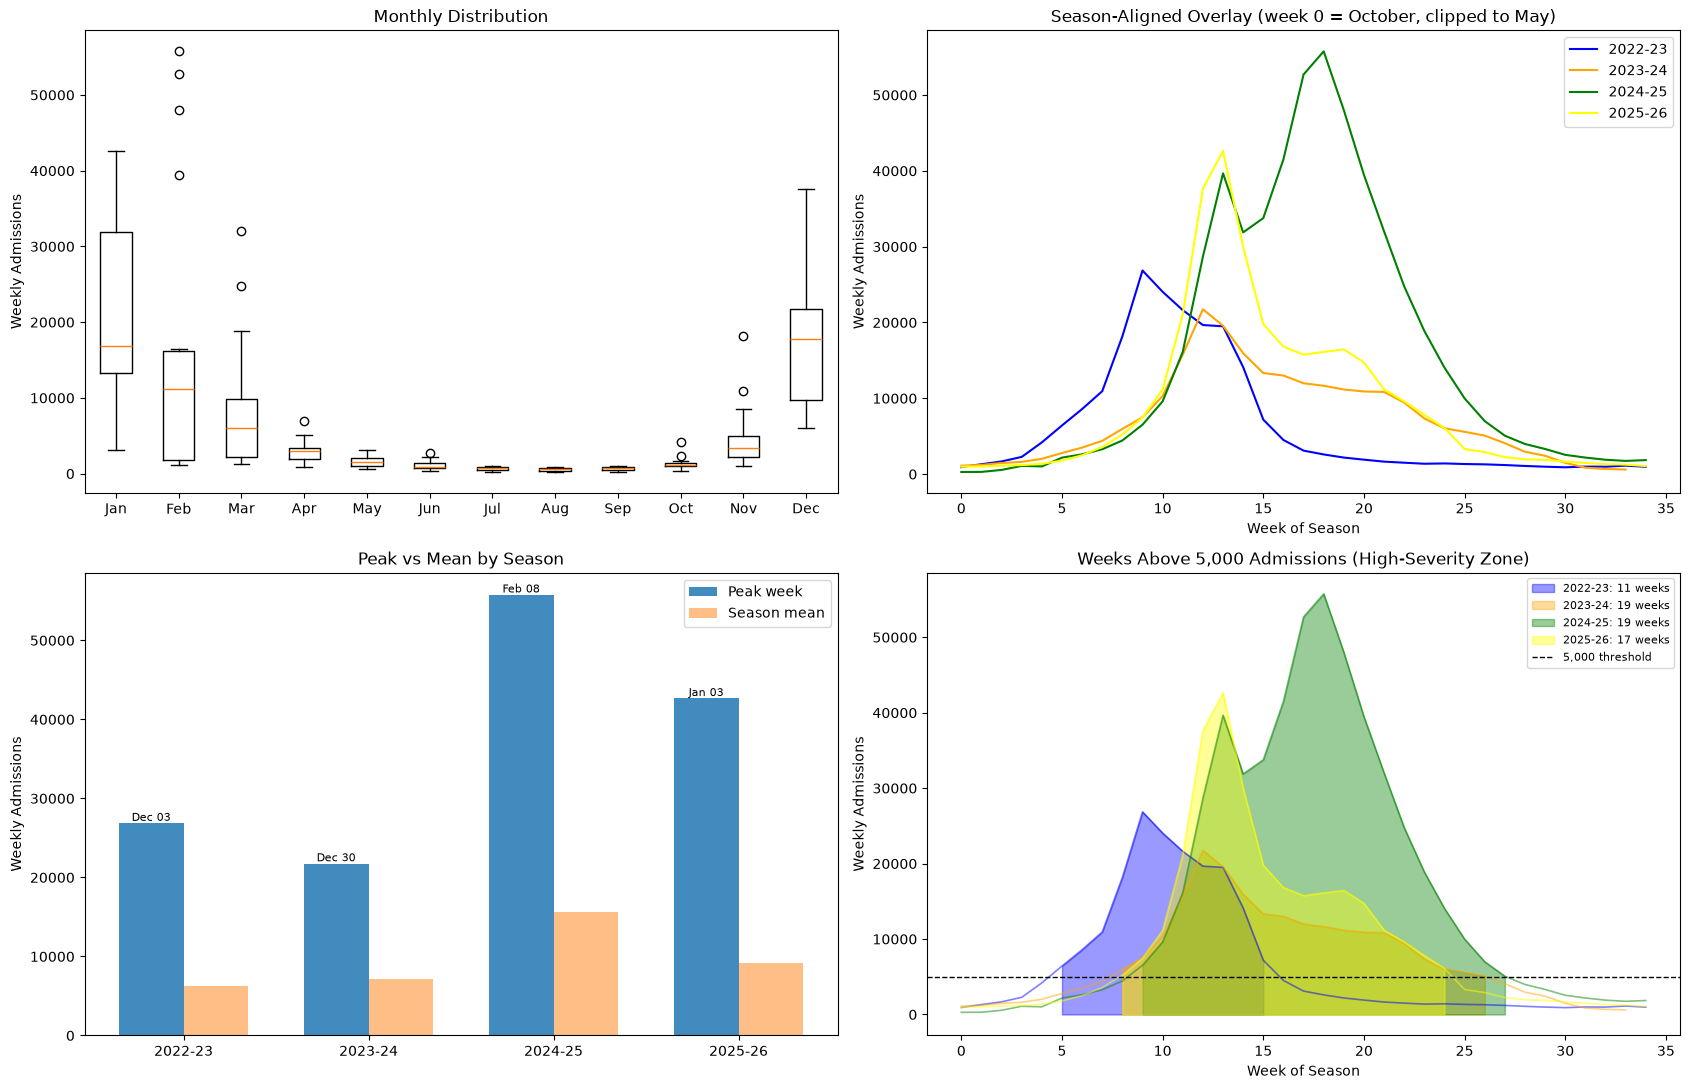

In [188]:
# --- Plots with all fixes applied ---
fig, axes = plt.subplots(2, 2, figsize=(17, 11))

season_colors = {
    "2022-23": "blue",
    "2023-24": "orange",
    "2024-25": "green",
    "2025-26": "yellow",
}

# --- Top left: Monthly boxplot (unchanged, uses full nhsn) ---
nhsn["month_abbr"] = nhsn["date"].dt.strftime("%b")
month_order = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]
data_by_month = [
    nhsn[nhsn["month_abbr"] == m]["weekly_admissions"].values for m in month_order
]
axes[0, 0].boxplot(data_by_month, tick_labels=month_order)
axes[0, 0].set_title("Monthly Distribution")
axes[0, 0].set_ylabel("Weekly Admissions")

# --- Top right: Season-aligned overlay (now uses nhsn_active, clipped to Oct–May) ---
for season, col in season_colors.items():
    seg = nhsn_active[nhsn_active["season"] == season].reset_index(drop=True)
    seg["week_num"] = range(len(seg))
    axes[0, 1].plot(seg["week_num"], seg["weekly_admissions"], label=season, color=col)
axes[0, 1].set_title("Season-Aligned Overlay (week 0 = October, clipped to May)")
axes[0, 1].set_xlabel("Week of Season")
axes[0, 1].set_ylabel("Weekly Admissions")
axes[0, 1].legend()

# --- Bottom left: Peak vs mean per season (uses nhsn_active) ---
season_stats = []
for season in season_colors.keys():
    seg = nhsn_active[nhsn_active["season"] == season].dropna(
        subset=["weekly_admissions"]
    )
    if len(seg) == 0:
        continue
    peak_row = seg.loc[seg["weekly_admissions"].idxmax()]
    season_stats.append(
        {
            "season": season,
            "peak": peak_row["weekly_admissions"],
            "peak_date": peak_row["date"].strftime("%b %d"),
            "mean": seg["weekly_admissions"].mean(),
        }
    )

x = range(len(season_stats))
width = 0.35
axes[1, 0].bar(
    [i - width / 2 for i in x],
    [s["peak"] for s in season_stats],
    width,
    label="Peak week",
    alpha=0.85,
)
axes[1, 0].bar(
    [i + width / 2 for i in x],
    [s["mean"] for s in season_stats],
    width,
    label="Season mean",
    alpha=0.5,
)
axes[1, 0].set_xticks(list(x))
axes[1, 0].set_xticklabels([s["season"] for s in season_stats])
for i, s in enumerate(season_stats):
    axes[1, 0].text(
        i - width / 2, s["peak"] + 300, s["peak_date"], ha="center", fontsize=8
    )
axes[1, 0].set_title("Peak vs Mean by Season")
axes[1, 0].set_ylabel("Weekly Admissions")
axes[1, 0].legend()

# --- Bottom right: Weeks above 5,000 admissions (uses nhsn_active) ---
threshold = 5000
for season, col in season_colors.items():
    seg = nhsn_active[nhsn_active["season"] == season].reset_index(drop=True)
    seg["week_num"] = range(len(seg))
    axes[1, 1].fill_between(
        seg["week_num"],
        seg["weekly_admissions"],
        where=seg["weekly_admissions"] >= threshold,
        alpha=0.4,
        color=col,
        label=f"{season}: {(seg['weekly_admissions'] >= threshold).sum()} weeks",
    )
    axes[1, 1].plot(
        seg["week_num"], seg["weekly_admissions"], color=col, lw=1.2, alpha=0.5
    )
axes[1, 1].axhline(
    threshold, color="black", lw=1, ls="--", label=f"{threshold:,} threshold"
)
axes[1, 1].set_title("Weeks Above 5,000 Admissions (High-Severity Zone)")
axes[1, 1].set_xlabel("Week of Season")
axes[1, 1].set_ylabel("Weekly Admissions")
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()

From the plots, we can see that November is the high-variance onset month while December and January are the consistently severe months. 

Peak weeks are between 10-17 across the seasons, with 2024-25 being an outlier. 

The peak-to-mean ratio varies significantly across seasons, with 2024-25 being the most extreme.

Duration and peak height are independent, with 2022-23 peaking highest early but lasting shortest. The model needs to be able to predict both the onset timing and sustained burden, not just the peak week.

This analysis suggests that we should use `nhsn_active` (Oct–May) for all season-level feature engineering, exclude 2021-22 from any season-level aggregations, and that `week-of-season` is a meaningful feature as peaks cluster between weeks 10 and 17



### How many rapid-rise and rapid-decline weeks exist, and where in the season do they cluster?

We need to know if the hard-to-predict weeks happen randomly or concentrate at a specific point in the season. If they cluster at onset (October–November), that tells us the model needs to be especially sensitive in those early weeks.

In [189]:
# Compute week-over-week percentage change — grouped by season to prevent
# cross-season contamination
nhsn_active["wow_pct"] = (
    nhsn_active.groupby("season")["weekly_admissions"].pct_change() * 100
)

# Null out first week of each season explicitly as an additional guard
first_weeks = nhsn_active.groupby("season").head(1).index
nhsn_active.loc[first_weeks, "wow_pct"] = None

# Define thresholds
RISE_THRESH = 20
FALL_THRESH = -20

rapid_rise = nhsn_active[nhsn_active["wow_pct"] > RISE_THRESH].copy()
rapid_fall = nhsn_active[nhsn_active["wow_pct"] < FALL_THRESH].copy()
normal = nhsn_active[nhsn_active["wow_pct"].abs() <= RISE_THRESH].copy()

print(f"Rapid rise weeks (>+{RISE_THRESH}%): {len(rapid_rise)}")
print(f"Rapid fall weeks (>{abs(FALL_THRESH)}%): {len(rapid_fall)}")
print(f"Normal weeks: {len(normal)}")

print("\nRapid rise — week of season distribution:")
print(rapid_rise["week_of_season"].describe())

print("\nBy season:")
print(rapid_rise.groupby("season")["week_of_season"].apply(list))

Rapid rise weeks (>+20%): 40
Rapid fall weeks (>20%): 23
Normal weeks: 72

Rapid rise — week of season distribution:
count    40.000000
mean      7.650000
std       3.759092
min       1.000000
25%       5.000000
50%       7.500000
75%      10.000000
max      17.000000
Name: week_of_season, dtype: float64

By season:
season
2022-23        [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]
2023-24    [2.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0...
2024-25    [2.0, 3.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0...
2025-26          [5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0]
Name: week_of_season, dtype: object


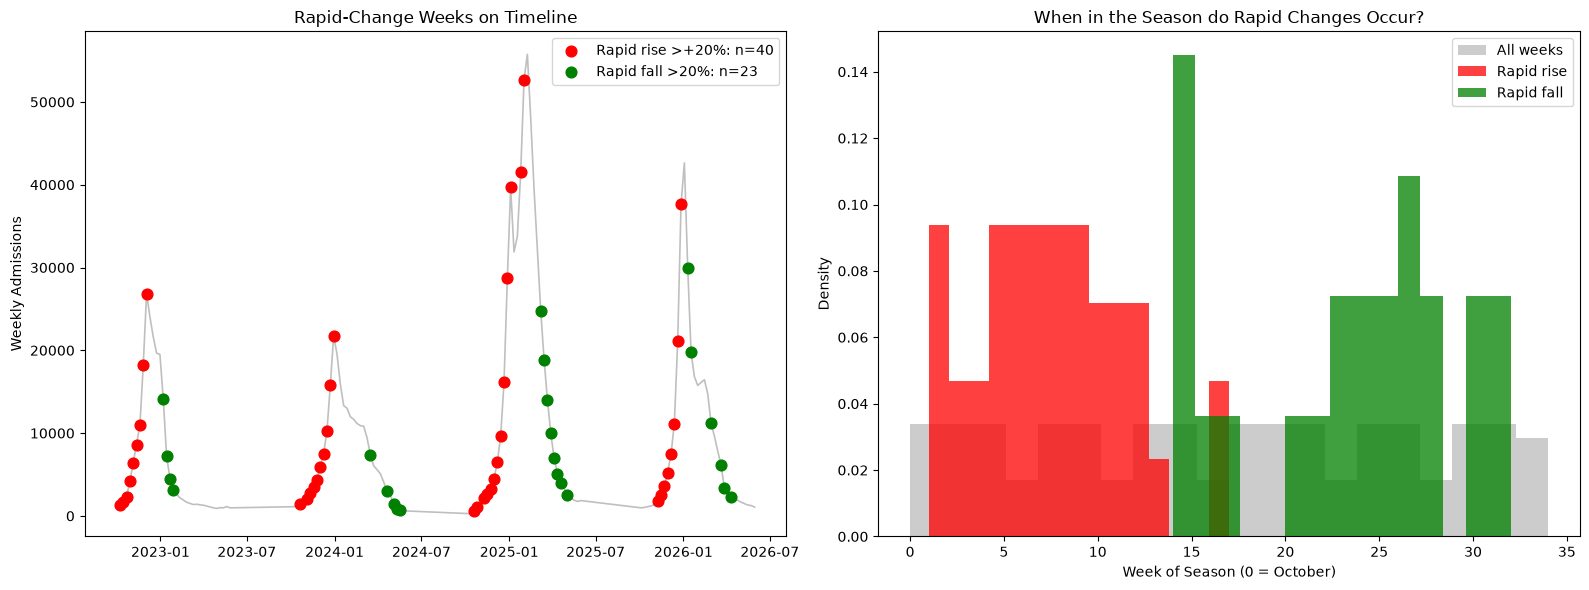

In [190]:
# Visualizing the rapid-change weeks on the timeline and their distribution across the season
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: timeline with rapid-change weeks highlighted
axes[0].plot(
    nhsn_active["date"],
    nhsn_active["weekly_admissions"],
    color="grey",
    lw=1.2,
    alpha=0.5,
)
axes[0].scatter(
    rapid_rise["date"],
    rapid_rise["weekly_admissions"],
    color="red",
    s=60,
    zorder=5,
    label=f"Rapid rise >+{RISE_THRESH}%: n={len(rapid_rise)}",
)
axes[0].scatter(
    rapid_fall["date"],
    rapid_fall["weekly_admissions"],
    color="green",
    s=60,
    zorder=5,
    label=f"Rapid fall >{abs(FALL_THRESH)}%: n={len(rapid_fall)}",
)
axes[0].set_title("Rapid-Change Weeks on Timeline")
axes[0].set_ylabel("Weekly Admissions")
axes[0].legend()

# Right: week-of-season histogram
axes[1].hist(
    nhsn_active["week_of_season"],
    bins=20,
    alpha=0.4,
    label="All weeks",
    density=True,
    color="grey",
)
axes[1].hist(
    rapid_rise["week_of_season"],
    bins=15,
    alpha=0.75,
    label="Rapid rise",
    density=True,
    color="red",
)
axes[1].hist(
    rapid_fall["week_of_season"],
    bins=15,
    alpha=0.75,
    label="Rapid fall",
    density=True,
    color="green",
)
axes[1].set_title("When in the Season do Rapid Changes Occur?")
axes[1].set_xlabel("Week of Season (0 = October)")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()

Rapid rise weeks (red) cluster tightly at the start of each season's climb, consistently appearing in the same position each year. Rapid fall weeks (green) are on the descending side of each peak, more spread out over several weeks. This asymmetry is important since the rise is fast and concentrated, the fall is slower and gradual.

The results confirm that the model's most critical forecasting window is weeks 1-10 of the flu season.

In [191]:
from scipy import stats

# Null out first week of each season to avoid cross-season contamination
first_weeks = nhsn_active.groupby("season").head(1).index
nhsn_active.loc[first_weeks, "wow_pct"] = None

# Create lag features
nhsn_active["lag1"] = nhsn_active["weekly_admissions"].shift(1)
nhsn_active["prev_wow"] = nhsn_active["wow_pct"].shift(1)
nhsn_active["is_rapid_rise"] = nhsn_active["wow_pct"] > RISE_THRESH

# Redefine groups after nulling first weeks
rapid_rise = nhsn_active[nhsn_active["wow_pct"] > RISE_THRESH].copy()
normal = nhsn_active[nhsn_active["wow_pct"].abs() <= RISE_THRESH].copy()

In [192]:
# Is prior-week admission level different before rapid-rise weeks?
clean_rise = rapid_rise.dropna(subset=["lag1"])
clean_normal = normal.dropna(subset=["lag1"])

_, p_level = stats.mannwhitneyu(clean_normal["lag1"], clean_rise["lag1"])
print(f"Prior-week level — Normal mean: {clean_normal['lag1'].mean():,.0f}")
print(f"Prior-week level — Rapid mean: {clean_rise['lag1'].mean():,.0f}")
print(f"Mann-Whitney p-value: {p_level:.4f}")

Prior-week level — Normal mean: 10,168
Prior-week level — Rapid mean: 7,857
Mann-Whitney p-value: 0.7568


In [193]:
# Is prior-week momentum different before rapid-rise weeks?
clean_rise_wow = nhsn_active[nhsn_active["is_rapid_rise"]]["prev_wow"].dropna()
clean_normal_wow = nhsn_active[~nhsn_active["is_rapid_rise"]]["prev_wow"].dropna()

_, p_momentum = stats.mannwhitneyu(clean_normal_wow, clean_rise_wow)
print(f"\nPrior WoW % — Normal mean: {clean_normal_wow.mean():.1f}%")
print(f"Prior WoW % — Rapid mean: {clean_rise_wow.mean():.1f}%")
print(f"Mann-Whitney p-value: {p_momentum:.4f}")


Prior WoW % — Normal mean: -8.8%
Prior WoW % — Rapid mean: 40.0%
Mann-Whitney p-value: 0.0000


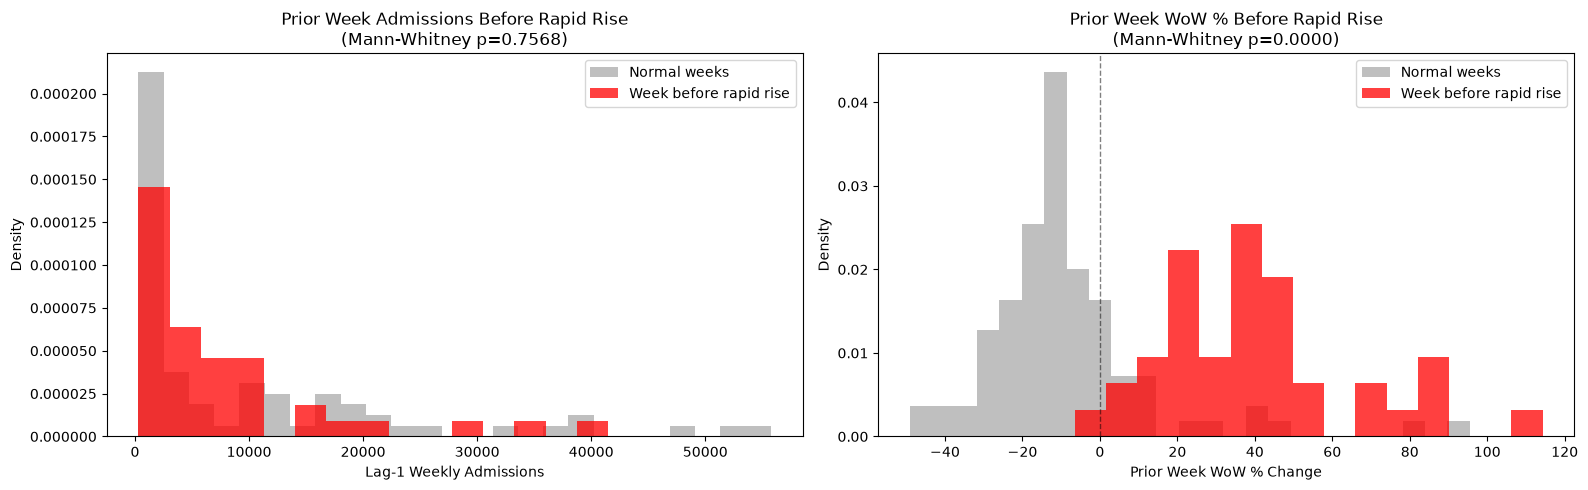

In [194]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: prior-week admission level
axes[0].hist(
    clean_normal["lag1"],
    bins=25,
    alpha=0.5,
    density=True,
    color="grey",
    label="Normal weeks",
)
axes[0].hist(
    clean_rise["lag1"],
    bins=15,
    alpha=0.75,
    density=True,
    color="red",
    label="Week before rapid rise",
)
axes[0].set_title(
    f"Prior Week Admissions Before Rapid Rise\n(Mann-Whitney p={p_level:.4f})"
)
axes[0].set_xlabel("Lag-1 Weekly Admissions")
axes[0].set_ylabel("Density")
axes[0].legend()

# Right: prior-week WoW momentum
axes[1].hist(
    clean_normal_wow,
    bins=25,
    alpha=0.5,
    density=True,
    color="grey",
    label="Normal weeks",
)
axes[1].hist(
    clean_rise_wow,
    bins=15,
    alpha=0.75,
    density=True,
    color="red",
    label="Week before rapid rise",
)
axes[1].axvline(0, color="black", lw=1, ls="--", alpha=0.5)
axes[1].set_title(
    f"Prior Week WoW % Before Rapid Rise\n(Mann-Whitney p={p_momentum:.4f})"
)
axes[1].set_xlabel("Prior Week WoW % Change")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()

The raw admission count the week before a rapid-rise (mean 7,857) is actually lower than normal weeks (mean 10,168). This makes sense as rapid rises happen early in the season when admissions are still building from a low base. The p-value of 0.76 confirms the level alone carries no predictive signal for whether next week will be a rapid rise. Therefore, raw lagged admissions alone are not enough.

For prior-week momentum, the mean WoW change of +40%, versus -8.8% for normal weeks, is a strong signal that the model can use to predict rapid rises. Also, the rapid rises do not happen randomly, but cluster tightly in the early weeks of the season. The p-value of 0.0001 confirms that prior-week momentum is a strong predictor of rapid rises. We should include prior-week momentum as a feature in the model, and the model should be especially sensitive to this feature in the early weeks of the season.

### At what lag does predictive power meaningfully drop off?

This directly determines the input window size for the model since if it is too short, we can miss a useful signal and if it is too long, we can add noise. The ACF and R² by lag together tell us the optimal lookback period.

We use it to understand how far back in time we can look to predict the next week's admissions. The ACF shows that the correlation drops off sharply after 4 weeks, and the R² also decreases significantly after 4 weeks. This suggests that a lookback period of 4 weeks is optimal for our model.

In [195]:
from scipy import stats

max_lag = 20

# Autocorrelation at each lag
acf_vals = [
    nhsn_active["weekly_admissions"].autocorr(lag=i) for i in range(1, max_lag + 1)
]

# R² (linear predictive power) at each lag
r2_vals = []
for lag in range(1, max_lag + 1):
    lagged = nhsn_active["weekly_admissions"].shift(lag)
    mask = lagged.notna()
    _, _, r, _, _ = stats.linregress(
        lagged[mask], nhsn_active["weekly_admissions"][mask]
    )
    r2_vals.append(r**2)

# Print summary table
print(f"{'Lag':<6} {'ACF':>8} {'R²':>8}")
print("-" * 24)
for i, (acf, r2) in enumerate(zip(acf_vals, r2_vals), 1):
    marker = " ← drop-off" if r2 < 0.5 and r2_vals[i - 2] >= 0.5 else ""
    print(f"{i:<6} {acf:>8.3f} {r2:>8.3f}{marker}")

Lag         ACF       R²
------------------------
1         0.947    0.897
2         0.831    0.691
3         0.704    0.496 ← drop-off
4         0.581    0.338
5         0.451    0.204
6         0.311    0.097
7         0.171    0.029
8         0.039    0.002
9        -0.076    0.006
10       -0.170    0.029
11       -0.249    0.062
12       -0.314    0.098
13       -0.362    0.131
14       -0.394    0.155
15       -0.416    0.173
16       -0.430    0.185
17       -0.437    0.191
18       -0.436    0.190
19       -0.426    0.181
20       -0.405    0.164


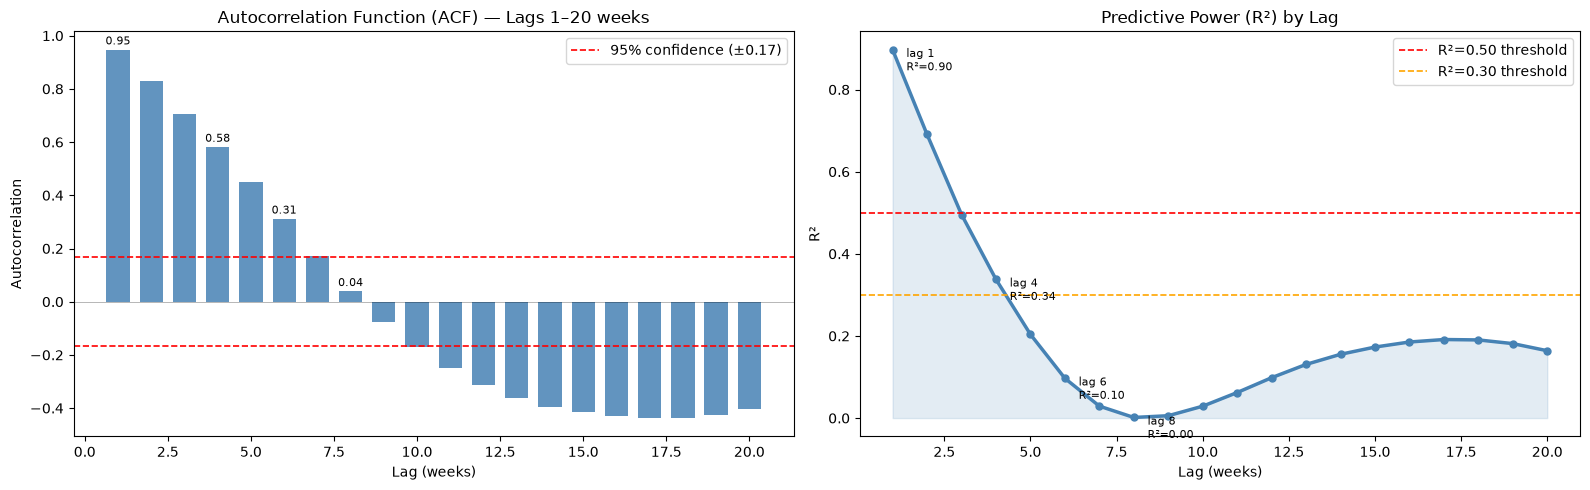

In [196]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

conf = 1.96 / np.sqrt(len(nhsn_active))

# Left: ACF bar chart
axes[0].bar(range(1, max_lag + 1), acf_vals, color="steelblue", alpha=0.85, width=0.7)
axes[0].axhline(
    conf, color="red", lw=1.2, ls="--", label=f"95% confidence (±{conf:.2f})"
)
axes[0].axhline(-conf, color="red", lw=1.2, ls="--")
axes[0].axhline(0, color="black", lw=0.5, alpha=0.4)
axes[0].set_title("Autocorrelation Function (ACF) — Lags 1–20 weeks")
axes[0].set_xlabel("Lag (weeks)")
axes[0].set_ylabel("Autocorrelation")
axes[0].legend()

# Annotate key lags
for lag in [1, 4, 6, 8]:
    axes[0].text(
        lag,
        acf_vals[lag - 1] + 0.02,
        f"{acf_vals[lag - 1]:.2f}",
        ha="center",
        fontsize=8,
    )

# Right: R² by lag with 0.5 threshold line
axes[1].plot(
    range(1, max_lag + 1), r2_vals, color="steelblue", lw=2.5, marker="o", ms=5
)
axes[1].fill_between(range(1, max_lag + 1), r2_vals, alpha=0.15, color="steelblue")
axes[1].axhline(0.5, color="red", lw=1.2, ls="--", label="R²=0.50 threshold")
axes[1].axhline(0.3, color="orange", lw=1.2, ls="--", label="R²=0.30 threshold")
axes[1].set_title("Predictive Power (R²) by Lag")
axes[1].set_xlabel("Lag (weeks)")
axes[1].set_ylabel("R²")
axes[1].legend()

# Annotate key lags
for lag in [1, 4, 6, 8]:
    axes[1].annotate(
        f"lag {lag}\nR²={r2_vals[lag-1]:.2f}",
        xy=(lag, r2_vals[lag - 1]),
        xytext=(lag + 0.4, r2_vals[lag - 1] - 0.05),
        fontsize=8,
    )

plt.tight_layout()
plt.show()

Lag 1 (R²=0.897) and lag 2 (R²=0.691) are by far the most predictive. The last week and the week before explain the vast majority of variance in current admissions

In lags 3 and 4, the R² drops to 0.496 and 0.338 respectively, indicating that while there is still some predictive power, it is significantly less than the first two lags. Beyond lag 4, the R² continues to decrease, suggesting that including additional weeks beyond this point may not provide meaningful predictive value and could introduce noise into the model.

The nagative ACF at lags 9-20 is a consequence of clipping to active months (Oct–May). The ACF is calculated on the full series, but the model will only see the active months. The negative correlation at lags 9-20 is an artifact of the seasonal cycle and does not reflect a true predictive relationship.

### Does a rolling average systematically lag at turning points, confirming a naive model will underperform there?

In [197]:
# Compute rolling mean baselines (shift(1) ensures no data leakage —
# we only use information available before the week we are predicting)
nhsn_active["roll4"] = nhsn_active["weekly_admissions"].rolling(4).mean().shift(1)
nhsn_active["roll6"] = nhsn_active["weekly_admissions"].rolling(6).mean().shift(1)

# Compute errors for both rolling windows
nhsn_active["roll4_err"] = nhsn_active["weekly_admissions"] - nhsn_active["roll4"]
nhsn_active["roll6_err"] = nhsn_active["weekly_admissions"] - nhsn_active["roll6"]

# Flag rapid-rise weeks
nhsn_active["is_rapid_rise"] = nhsn_active["wow_pct"] > RISE_THRESH

In [198]:
# Compare error at rapid-rise vs normal weeks
rapid = nhsn_active[nhsn_active["is_rapid_rise"]].dropna(subset=["roll4_err"])
normal = nhsn_active[~nhsn_active["is_rapid_rise"]].dropna(subset=["roll4_err"])

print("Rolling 4-week mean performance:")
print(f"  Normal weeks  — MAE : {normal['roll4_err'].abs().mean():,.0f}")
print(f"  Rapid-rise    — MAE : {rapid['roll4_err'].abs().mean():,.0f}")
print(
    f"  Ratio (rapid / normal): {rapid['roll4_err'].abs().mean() / normal['roll4_err'].abs().mean():.1f}x worse"
)

print("\nRolling 6-week mean performance:")
rapid6 = nhsn_active[nhsn_active["is_rapid_rise"]].dropna(subset=["roll6_err"])
normal6 = nhsn_active[~nhsn_active["is_rapid_rise"]].dropna(subset=["roll6_err"])
print(f"  Normal weeks  — MAE : {normal6['roll6_err'].abs().mean():,.0f}")
print(f"  Rapid-rise    — MAE : {rapid6['roll6_err'].abs().mean():,.0f}")
print(
    f"  Ratio (rapid / normal): {rapid6['roll6_err'].abs().mean() / normal6['roll6_err'].abs().mean():.1f}x worse"
)

Rolling 4-week mean performance:
  Normal weeks  — MAE : 3,880
  Rapid-rise    — MAE : 6,299
  Ratio (rapid / normal): 1.6x worse

Rolling 6-week mean performance:
  Normal weeks  — MAE : 5,215
  Rapid-rise    — MAE : 7,648
  Ratio (rapid / normal): 1.5x worse


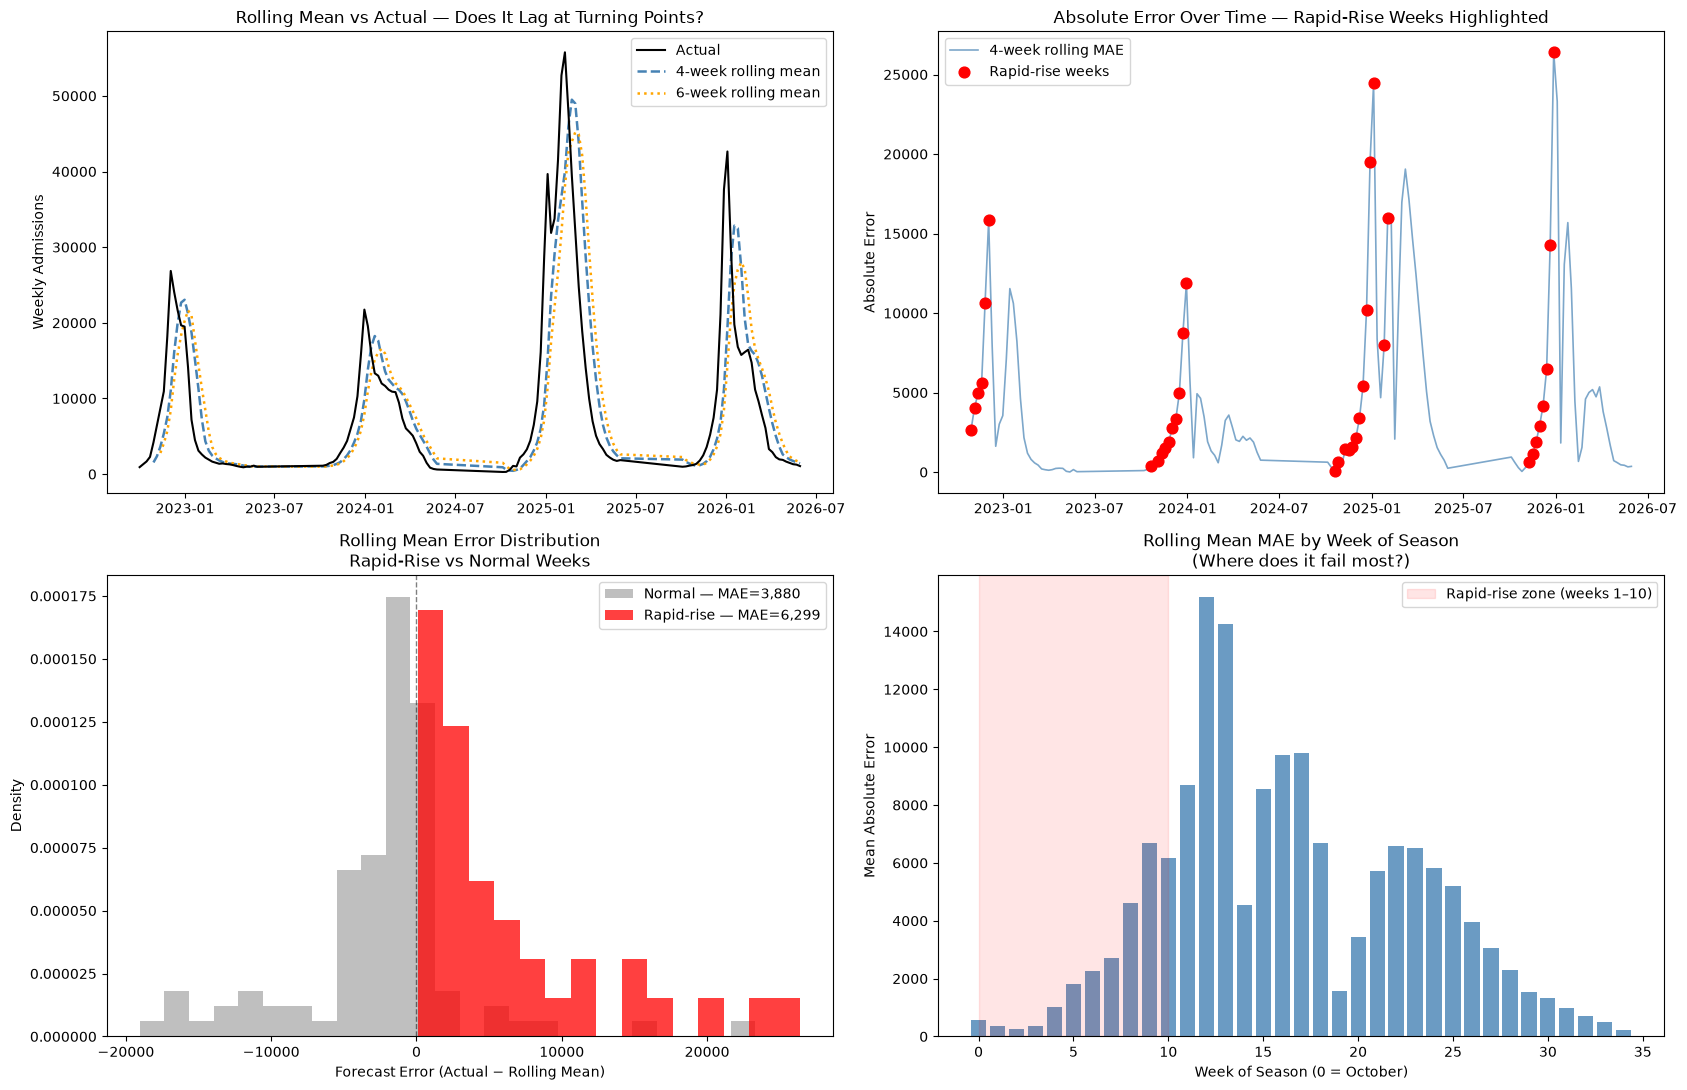

In [199]:
fig, axes = plt.subplots(2, 2, figsize=(17, 11))

# Top left: rolling mean vs actual over time
axes[0, 0].plot(
    nhsn_active["date"],
    nhsn_active["weekly_admissions"],
    color="black",
    lw=1.5,
    label="Actual",
    zorder=3,
)
axes[0, 0].plot(
    nhsn_active["date"],
    nhsn_active["roll4"],
    color="steelblue",
    lw=1.8,
    ls="--",
    label="4-week rolling mean",
)
axes[0, 0].plot(
    nhsn_active["date"],
    nhsn_active["roll6"],
    color="orange",
    lw=1.8,
    ls=":",
    label="6-week rolling mean",
)
axes[0, 0].set_title("Rolling Mean vs Actual — Does It Lag at Turning Points?")
axes[0, 0].set_ylabel("Weekly Admissions")
axes[0, 0].legend()

# Top right: absolute error over time, rapid-rise weeks highlighted
axes[0, 1].plot(
    nhsn_active["date"],
    nhsn_active["roll4_err"].abs(),
    color="steelblue",
    lw=1.2,
    alpha=0.7,
    label="4-week rolling MAE",
)
axes[0, 1].scatter(
    rapid["date"],
    rapid["roll4_err"].abs(),
    color="red",
    s=60,
    zorder=5,
    label="Rapid-rise weeks",
)
axes[0, 1].set_title("Absolute Error Over Time — Rapid-Rise Weeks Highlighted")
axes[0, 1].set_ylabel("Absolute Error")
axes[0, 1].legend()

# Bottom left: error distribution rapid-rise vs normal
axes[1, 0].hist(
    normal["roll4_err"],
    bins=25,
    alpha=0.5,
    density=True,
    color="grey",
    label=f'Normal — MAE={normal["roll4_err"].abs().mean():,.0f}',
)
axes[1, 0].hist(
    rapid["roll4_err"],
    bins=15,
    alpha=0.75,
    density=True,
    color="red",
    label=f'Rapid-rise — MAE={rapid["roll4_err"].abs().mean():,.0f}',
)
axes[1, 0].axvline(0, color="black", lw=1, ls="--", alpha=0.5)
axes[1, 0].set_title("Rolling Mean Error Distribution\nRapid-Rise vs Normal Weeks")
axes[1, 0].set_xlabel("Forecast Error (Actual − Rolling Mean)")
axes[1, 0].set_ylabel("Density")
axes[1, 0].legend()

# Bottom right: error by week of season
week_err = (
    nhsn_active.groupby("week_of_season")["roll4_err"]
    .apply(lambda x: x.abs().mean())
    .reset_index()
)
week_err.columns = ["week_of_season", "mae"]
axes[1, 1].bar(
    week_err["week_of_season"], week_err["mae"], color="steelblue", alpha=0.8
)
axes[1, 1].axvspan(0, 10, alpha=0.1, color="red", label="Rapid-rise zone (weeks 1–10)")
axes[1, 1].set_title("Rolling Mean MAE by Week of Season\n(Where does it fail most?)")
axes[1, 1].set_xlabel("Week of Season (0 = October)")
axes[1, 1].set_ylabel("Mean Absolute Error")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

The rolling mean analysis confirms that a naive baseline has a systematic and predictable failure mode. Both the 4-week and 6-week rolling means track the series reasonably well during steady periods, but consistently undershoot at turning points, arriving late and never fully reaching actual peak values. 

The 4-week rolling mean performs better than the 6-week (MAE of 3,880 vs 5,215 on normal weeks), confirming that a shorter lookback window is more appropriate for this data. At rapid-rise weeks the 4-week rolling mean is 1.6x worse than at normal weeks (MAE 6,299 vs 3,880), and critically, the error is almost entirely one-directional as the rolling mean underpredicts at onset, never overpredicts. 

The week-of-season error chart refines our understanding of where the model must improve: the highest absolute errors occur at weeks 10–15 rather than weeks 1–10, because admissions in the early onset weeks are still low in absolute magnitude. 

The real challenge is the peak approach phase when admissions are already large and still accelerating. This establishes a clear and measurable bar for the deep learning model as it must outperform a MAE of 6,299 on rapid-rise weeks and do so specifically in weeks 10–15 of the season, where the rolling mean fails most severely in absolute terms.

### Do states peak at meaningfully different times, or is the national series a reliable aggregate?

In [200]:
state = pd.read_csv("data/state_hosp.csv", parse_dates=["date"])

# Filter to 2024-25 season active months only
s24 = state[state["date"].between("2024-10-01", "2025-05-31")].copy()

# National peak date for reference
n24 = nhsn_active[nhsn_active["season"] == "2024-25"].copy()
nat_peak_date = n24.loc[n24["weekly_admissions"].idxmax(), "date"]
print(f"National peak: {nat_peak_date.date()}")

National peak: 2025-02-08


In [201]:
# Peak date per state
peak_dates = (
    s24.groupby("location_name")
    .apply(lambda x: x.loc[x["value"].idxmax(), "date"])
    .reset_index()
)
peak_dates.columns = ["state", "peak_date"]
peak_dates["days_from_nat"] = (peak_dates["peak_date"] - nat_peak_date).dt.days
peak_dates = peak_dates.sort_values("days_from_nat").reset_index(drop=True)

print(f"\nState peak spread:")
print(f"Std dev: {peak_dates['days_from_nat'].std():.1f} days")
print(
    f"Range: {peak_dates['days_from_nat'].min()} to {peak_dates['days_from_nat'].max()} days"
)
print(f"\nEarliest peaking states:")
print(peak_dates.head(5).to_string(index=False))
print(f"\nLatest peaking states:")
print(peak_dates.tail(5).to_string(index=False))


State peak spread:
Std dev: 16.3 days
Range: -42 to 14 days

Earliest peaking states:
     state  peak_date  days_from_nat
     Idaho 2024-12-28            -42
   Wyoming 2025-01-04            -35
    Nevada 2025-01-04            -35
    Hawaii 2025-01-04            -35
New Mexico 2025-01-04            -35

Latest peaking states:
        state  peak_date  days_from_nat
     Missouri 2025-02-15              7
New Hampshire 2025-02-22             14
      Montana 2025-02-22             14
     Michigan 2025-02-22             14
West Virginia 2025-02-22             14


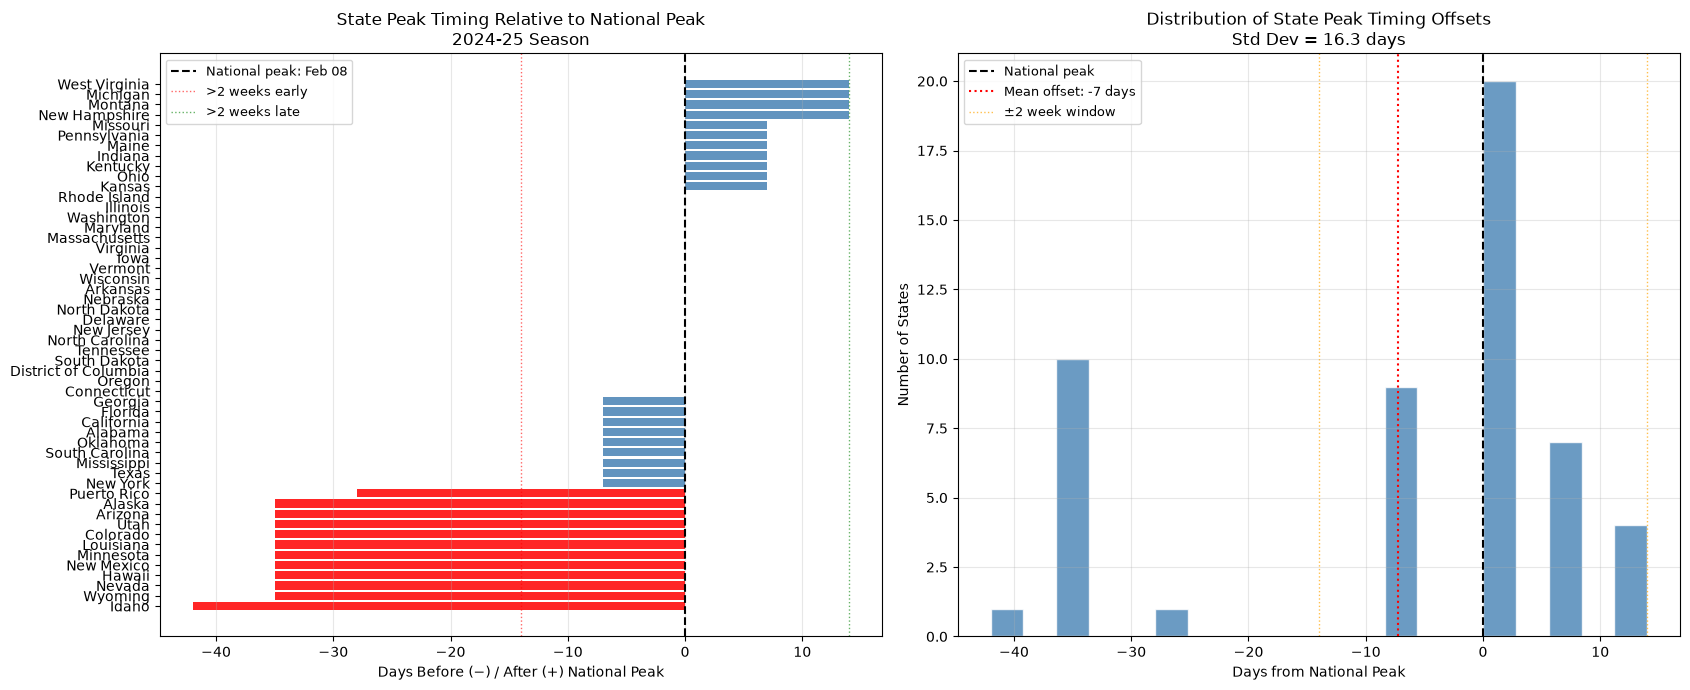

In [202]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# Left: horizontal bar chart of days from national peak
colors = [
    "red" if d < -14 else "green" if d > 14 else "steelblue"
    for d in peak_dates["days_from_nat"]
]
axes[0].barh(peak_dates["state"], peak_dates["days_from_nat"], color=colors, alpha=0.85)
axes[0].axvline(
    0,
    color="black",
    lw=1.5,
    ls="--",
    label=f'National peak: {nat_peak_date.strftime("%b %d")}',
)
axes[0].axvline(-14, color="red", lw=1, ls=":", alpha=0.6, label=">2 weeks early")
axes[0].axvline(14, color="green", lw=1, ls=":", alpha=0.6, label=">2 weeks late")
axes[0].set_title("State Peak Timing Relative to National Peak\n2024-25 Season")
axes[0].set_xlabel("Days Before (−) / After (+) National Peak")
axes[0].legend(fontsize=9)
axes[0].grid(True, axis="x", alpha=0.3)

# Right: distribution of offsets
axes[1].hist(
    peak_dates["days_from_nat"],
    bins=20,
    color="steelblue",
    alpha=0.8,
    edgecolor="white",
)
axes[1].axvline(0, color="black", lw=1.5, ls="--", label="National peak")
axes[1].axvline(
    peak_dates["days_from_nat"].mean(),
    color="red",
    lw=1.5,
    ls=":",
    label=f"Mean offset: {peak_dates['days_from_nat'].mean():.0f} days",
)
axes[1].axvline(-14, color="orange", lw=1, ls=":", alpha=0.7)
axes[1].axvline(14, color="orange", lw=1, ls=":", alpha=0.7, label="±2 week window")
axes[1].set_title(
    f"Distribution of State Peak Timing Offsets\nStd Dev = {peak_dates['days_from_nat'].std():.1f} days"
)
axes[1].set_xlabel("Days from National Peak")
axes[1].set_ylabel("Number of States")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The 56-day spread (−42 to +14 days) with a standard deviation of 16.3 days means states are not peaking together as they are peaking across a roughly 8-week window around the national figure.

The blue states (roughly 25 of them) peaked within ±2 weeks of the national peak and are well-served by a national model.

The red states (roughly 20 of them) peaked more than 2 weeks early, concentrated in the west and mountain regions such as Idaho, Wyoming, Nevada, Hawaii, New Mexico all peaked 5–6 weeks before the national peak.

### Which states are most out of sync with the national trend?

Peak timing from Q9 tells us when states diverge. Correlation tells us how consistently they diverge across the entire season as a state can peak at the same time as the national but still behave very differently week to week.

In [203]:
from scipy import stats

nhsn_nat = pd.read_csv("data/combined_flu_us.csv", parse_dates=["date"])
nhsn_nat = (
    nhsn_nat[nhsn_nat["date"] >= "2022-02-05"]
    .sort_values("date")
    .reset_index(drop=True)
)

# Pearson correlation of each state's full weekly series with national trend
state_corrs = []
for st in state["location_name"].unique():
    merged = pd.merge(
        state[state["location_name"] == st][["date", "value"]].rename(
            columns={"value": "state_val"}
        ),
        nhsn_nat[["date", "weekly_admissions"]],
        on="date",
    ).dropna()
    if len(merged) < 10:
        continue
    r, p = stats.pearsonr(merged["state_val"], merged["weekly_admissions"])
    state_corrs.append({"state": st, "r": round(r, 4), "p": round(p, 4)})

corr_df = pd.DataFrame(state_corrs).sort_values("r").reset_index(drop=True)

print("Most out-of-sync states:")
print(corr_df.head(5).to_string(index=False))
print("\nMost in-sync states:")
print(corr_df.tail(5).to_string(index=False))

# How many states fall below each threshold?
print(f"\nStates with r < 0.70 : {(corr_df['r'] < 0.70).sum()}")
print(f"States with r < 0.85 : {(corr_df['r'] < 0.85).sum()}")
print(f"States with r >= 0.85: {(corr_df['r'] >= 0.85).sum()}")

Most out-of-sync states:
      state      r   p
Puerto Rico 0.6348 0.0
    Arizona 0.7196 0.0
     Alaska 0.7864 0.0
     Nevada 0.8027 0.0
     Oregon 0.8307 0.0

Most in-sync states:
     state      r   p
  Virginia 0.9624 0.0
 Wisconsin 0.9625 0.0
 Tennessee 0.9676 0.0
New Jersey 0.9772 0.0
  Illinois 0.9888 0.0

States with r < 0.70 : 1
States with r < 0.85 : 6
States with r >= 0.85: 46


First, The national model is broadly valid. 46 out of 52 states (88%) have r ≥ 0.85 with the national trend as they move closely in sync with the aggregate series week to week. A national model will serve the vast majority of states well.

Puerto Rico is the single state below r=0.70 (r=0.635) as its weekly pattern is structurally different from the continental US trend. This is not surprising given its geography, different climate seasonality, and distinct healthcare reporting structure. It should be excluded from any national model evaluation or treated as a separate case entirely.

Arizona, Alaska, Nevada, Oregon, and Puerto Rico all fall below r=0.85. All five are either geographically isolated or in the western/mountain region and consistent with the early-peaking cluster we identified earlier. Their lower correlation is driven by timing divergence more than shape divergence.

Illinois (r=0.989), New Jersey (r=0.977), Tennessee (r=0.968) are large, densely populated states whose size means they heavily influence the national aggregate, so their high correlation is partly self-fulfilling.

### Does the composite search index track the flu season pattern?

If it does not follow the same seasonal shape as admissions, it adds noise not signal.

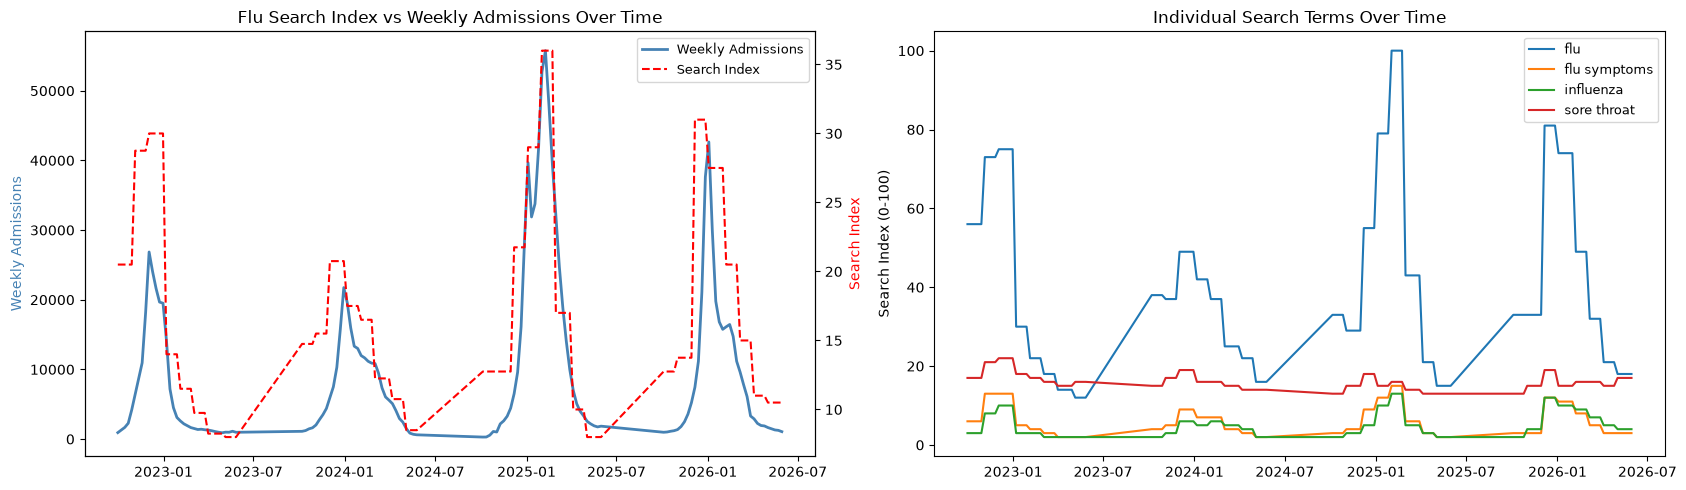

In [204]:
# Align trends_weekly with nhsn_active for comparison
trends_active = trends_weekly[
    trends_weekly["date"].dt.month.isin([10, 11, 12, 1, 2, 3, 4, 5])
].copy()

fig, axes = plt.subplots(1, 2, figsize=(17, 5))

# Left: search index over time vs admissions (dual axis)
ax1 = axes[0]
ax2 = ax1.twinx()

ax1.plot(
    nhsn_active["date"],
    nhsn_active["weekly_admissions"],
    color="steelblue",
    lw=2,
    label="Weekly Admissions",
)
ax2.plot(
    trends_active["date"],
    trends_active["flu_search_index"],
    color="red",
    lw=1.5,
    ls="--",
    label="Search Index",
)

ax1.set_ylabel("Weekly Admissions", color="steelblue")
ax2.set_ylabel("Search Index", color="red")
ax1.set_title("Flu Search Index vs Weekly Admissions Over Time")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

# Right: individual terms over time
for term in ["flu", "flu symptoms", "influenza", "sore throat"]:
    axes[1].plot(trends_active["date"], trends_active[term], label=term, lw=1.5)
axes[1].set_title("Individual Search Terms Over Time")
axes[1].set_ylabel("Search Index (0-100)")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

The search index seems to track the flu season pattern reasonably well, with peaks generally aligning with the peaks in hospital admissions. However, the search index peaks slightly earlier than the hospital admissions, which is expected as people search for symptoms before seeking medical care. The 2022-23 search peak appears earlier and higher relative to admissions compared to later seasons.

### Which Individual terms correlate most strongly with admissions?

We seek to understand whether all four search terms deserve equal weight in the composite index or if some should be dropped or up-weighted.

In [205]:
from scipy import stats

# Merge trends with nhsn_active on date for correlation analysis
merged_eda = pd.merge(
    nhsn_active[["date", "weekly_admissions"]],
    trends_weekly[
        ["date", "flu_search_index", "flu", "flu symptoms", "influenza", "sore throat"]
    ],
    on="date",
    how="inner",
).dropna()

print(f"Merged rows for EDA: {len(merged_eda)}")
print(f"\n{'Term':<20} {'r':>8} {'p':>10}")
print("-" * 40)

terms = ["flu_search_index", "flu", "flu symptoms", "influenza", "sore throat"]
corr_results = {}
for term in terms:
    r, p = stats.pearsonr(merged_eda[term], merged_eda["weekly_admissions"])
    corr_results[term] = {"r": r, "p": p}
    print(f"{term:<20} {r:>8.3f} {p:>10.4f}")

Merged rows for EDA: 139

Term                        r          p
----------------------------------------
flu_search_index        0.798     0.0000
flu                     0.795     0.0000
flu symptoms            0.808     0.0000
influenza               0.813     0.0000
sore throat             0.240     0.0044


Based on the correlation analysis, `sore throat` is clearly weaker than other terms. 

### Does the search index lead hospitalizations by 1-4 weeks?

We assume search volume should peak before hospitalizations if it is a genuine leading indicator. This confirms whether lag-1 or a longer lag is more appropriate.

In [206]:
print(f"{'Lag':<6} {'r':>8} {'p':>10}")
print("-" * 26)

for lag in range(0, 5):
    merged_eda[f"search_lag{lag}"] = merged_eda["flu_search_index"].shift(lag)
    clean = merged_eda.dropna(subset=[f"search_lag{lag}", "weekly_admissions"])
    r, p = stats.pearsonr(clean[f"search_lag{lag}"], clean["weekly_admissions"])
    marker = " ← best" if lag == 1 else ""
    print(f"{lag:<6} {r:>8.3f} {p:>10.6f}{marker}")

Lag           r          p
--------------------------
0         0.798   0.000000
1         0.827   0.000000 ← best
2         0.822   0.000000
3         0.778   0.000000
4         0.679   0.000000


`Lag-1` is the most predictive, with a correlation of 0.827 as `r` increases from 0.798 at `lag-0` to 0.827 at `lag-1`. It stays high at `lag-2` (0.822). 

### Does the search index behave differently at rapid-rise weeks than at normal weeks?

If search volume is already elevated the week before a rapid rise, it adds genuine early warning signal on top of what the momentum features already provide.

Prior-week search index — Normal mean : 15.67
Prior-week search index — Rapid mean  : 19.68
Mann-Whitney p-value                  : 0.0001


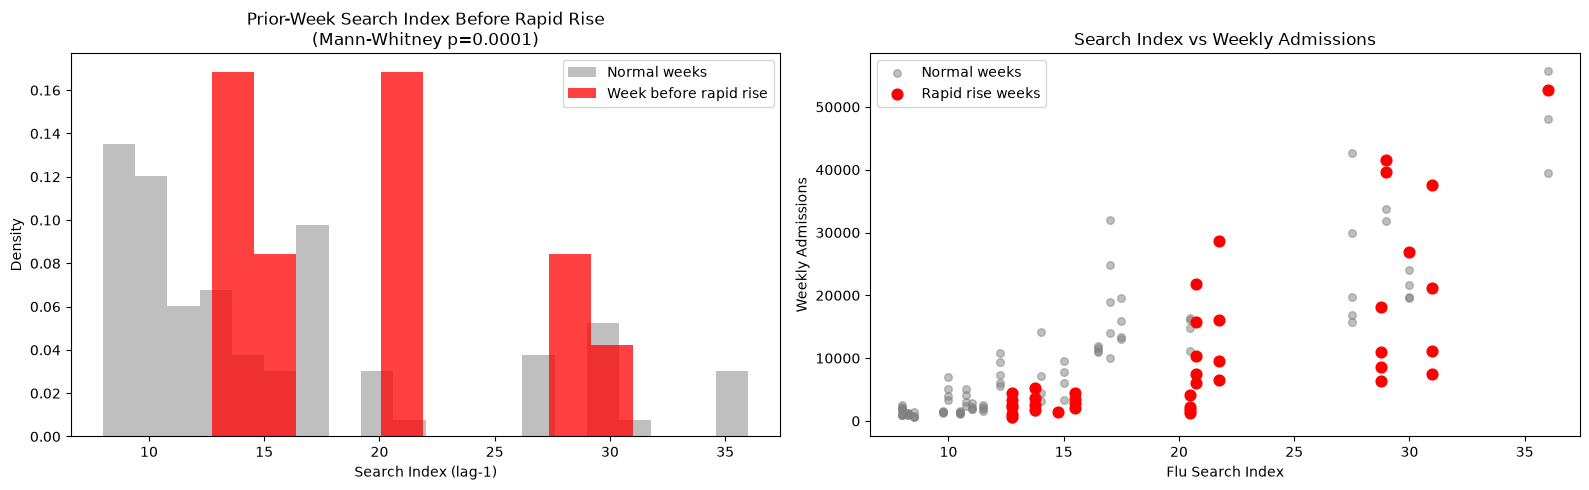

In [207]:
# Merge rapid rise flag with search data
merged_rapid = pd.merge(
    nhsn_active[["date", "weekly_admissions", "wow_pct", "is_rapid_rise"]],
    trends_weekly[["date", "flu_search_index"]],
    on="date",
    how="inner",
).dropna()

# Lag search index by 1 week
merged_rapid["search_lag1"] = merged_rapid["flu_search_index"].shift(1)

rapid_search = merged_rapid[merged_rapid["is_rapid_rise"]].dropna(
    subset=["search_lag1"]
)
normal_search = merged_rapid[~merged_rapid["is_rapid_rise"]].dropna(
    subset=["search_lag1"]
)

_, p_search = stats.mannwhitneyu(
    normal_search["search_lag1"], rapid_search["search_lag1"]
)

print(
    f"Prior-week search index — Normal mean : {normal_search['search_lag1'].mean():.2f}"
)
print(
    f"Prior-week search index — Rapid mean  : {rapid_search['search_lag1'].mean():.2f}"
)
print(f"Mann-Whitney p-value                  : {p_search:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(
    normal_search["search_lag1"],
    bins=20,
    alpha=0.5,
    density=True,
    color="grey",
    label="Normal weeks",
)
axes[0].hist(
    rapid_search["search_lag1"],
    bins=10,
    alpha=0.75,
    density=True,
    color="red",
    label="Week before rapid rise",
)
axes[0].set_title(
    f"Prior-Week Search Index Before Rapid Rise\n(Mann-Whitney p={p_search:.4f})"
)
axes[0].set_xlabel("Search Index (lag-1)")
axes[0].set_ylabel("Density")
axes[0].legend()

# Scatter: search index vs admissions, colored by rapid-rise
axes[1].scatter(
    merged_rapid[~merged_rapid["is_rapid_rise"]]["flu_search_index"],
    merged_rapid[~merged_rapid["is_rapid_rise"]]["weekly_admissions"],
    color="grey",
    alpha=0.5,
    s=30,
    label="Normal weeks",
)
axes[1].scatter(
    merged_rapid[merged_rapid["is_rapid_rise"]]["flu_search_index"],
    merged_rapid[merged_rapid["is_rapid_rise"]]["weekly_admissions"],
    color="red",
    s=60,
    zorder=5,
    label="Rapid rise weeks",
)
axes[1].set_title("Search Index vs Weekly Admissions")
axes[1].set_xlabel("Flu Search Index")
axes[1].set_ylabel("Weekly Admissions")
axes[1].legend()

plt.tight_layout()
plt.show()

Prior-week search index is significantly higher before rapid-rise weeks (19.68 vs 15.67, p=0.0001). The scatter plot shows rapid-rise weeks (red) concentrated at higher search index values (right side).

This is independent of `wow_pct_lag1` as search volume and prior-week momentum are different signals and both are statistically significant before rapid rises

In [208]:
# Dropping the sore throat term

trends_raw = trends_raw.drop(columns=["sore throat"])

# Build composite search index from three validated terms only
search_terms = ["flu", "flu symptoms", "influenza"]
trends_raw["flu_search_index"] = trends_raw[search_terms].mean(axis=1)

print("Search index stats:")
print(trends_raw["flu_search_index"].describe().round(3))

# Forward-fill monthly to weekly
trends_weekly = pd.merge(
    weekly_dates,
    trends_raw[["month", "flu_search_index"] + search_terms],
    on="month",
    how="left",
).drop(columns=["month"])

Search index stats:
count    45.000
mean     14.022
std       9.680
min       3.667
25%       6.333
50%      11.000
75%      18.000
max      42.667
Name: flu_search_index, dtype: float64


### EDA Summary

**EDA Summary**

The initial dataset combines two CDC sources, the older FluSight incident hospitalization series (2020–2022) and the NHSN series (2022–2026), merged into 338 continuous weekly national observations with no missing weeks or nulls. The analysis was restricted to active flu months (October–May) and four complete seasons (2022-23 through 2025-26).

The raw distribution is heavily right-skewed (skew=2.61), and log-transformation brings it to near-symmetry (skew=0.51). This confirms the model should train on log1p-transformed targets. Seasonality is consistent across years but peak magnitude varies substantially with the 2024-25 season peaking at 55,757 admissions, nearly double any prior season, and representing the critical generalization test for the model.

Rapid-rise weeks (>20% WoW growth) number 40 and cluster between weeks 1–17 of the season, with no rapid rises occurring in the second half. The prior week's raw admission level carries no predictive signal for onset (p=0.76), but prior week momentum does (p=0.0000, mean +40% vs −8.8% for normal weeks), confirming momentum features are essential. The rolling mean baseline is 1.6 times worse at rapid-rise weeks than normal weeks (MAE 6,299 vs 3,880), with the highest errors at weeks 10–15 rather than early onset, the specific window the model must improve on. Lag analysis confirms a 4-week input window, with R² dropping from 0.897 at lag-1 to near zero beyond lag-6.

At state level, 46 of 52 states correlate with the national trend at r ≥ 0.85, validating a national modeling approach. Puerto Rico (r=0.635) is the only genuinely out-of-sync state and should be excluded from evaluation. State peaks span a 56-day window, with western states peaking 5–6 weeks before the national figure.

Google Trends search data was evaluated as an exogenous leading indicator. The composite search index, built from `flu`, `flu symptoms`, and `influenza` after dropping `sore throat` (r=0.240, too general to be flu-specific), correlates with weekly admissions at r=0.827 at a one-week lag, confirming it genuinely leads hospitalizations. Critically, the prior-week search index is significantly elevated before rapid-rise weeks compared to normal weeks (mean 19.68 vs 15.67, p=0.0001), providing an early warning signal independent of the momentum features already captured by `wow_pct_lag1`. The search index lag-1 is therefore added as the 15th feature.

**The EDA confirms the following modeling decisions:**
- Target: `log1p(weekly_admissions)`, reversed with `expm1` at prediction time
- Input window to be 4 weeks (lags 1–4)
- Required features include lagged admissions, prior WoW momentum, week of season, month, and flu search index lag-1
- Baseline to beat is a rolling 4-week MAE of 6,299 on rapid-rise weeks
- Exclude Puerto Rico from national evaluation

Total features to be 15.


## Feature Engineering

Log transform the target variable as confirmed earlier.

In [209]:
import numpy as np

nhsn_active["target"] = np.log1p(nhsn_active["weekly_admissions"])

# Sanity check
print(nhsn_active[["weekly_admissions", "target"]].describe().round(3))

       weekly_admissions   target
count            139.000  139.000
mean            9594.942    8.439
std            11805.330    1.262
min              286.000    5.659
25%             1497.000    7.312
50%             4187.000    8.340
75%            13689.000    9.524
max            55757.000   10.929


Lags 1-4 carry meaningful predictive signal, so we will create lagged features for the target variable.

In [210]:
# Shift within season only and null out values that cross season boundaries
for lag in range(1, 5):
    nhsn_active[f"lag{lag}"] = nhsn_active.groupby("season")["weekly_admissions"].shift(
        lag
    )

# Log-transform the lag features to match the target scale
for lag in range(1, 5):
    nhsn_active[f"lag{lag}_log"] = np.log1p(nhsn_active[f"lag{lag}"])

print(nhsn_active[["lag1_log", "lag2_log", "lag3_log", "lag4_log"]].describe().round(3))

       lag1_log  lag2_log  lag3_log  lag4_log
count   135.000   131.000   127.000   123.000
mean      8.483     8.527     8.572     8.614
std       1.252     1.243     1.234     1.231
min       5.659     5.659     5.659     5.659
25%       7.399     7.416     7.515     7.565
50%       8.398     8.531     8.561     8.694
75%       9.553     9.576     9.631     9.665
max      10.929    10.929    10.929    10.929


Prior week WoW% change is a strong predictor of rapid rises, so we will create a feature for prior week WoW% change.

In [211]:
# WoW % change as already nulled at season boundaries
nhsn_active["wow_pct"] = (
    nhsn_active.groupby("season")["weekly_admissions"].pct_change() * 100
)

# Null first week of each season to prevent cross-season contamination
first_weeks = nhsn_active.groupby("season").head(1).index
nhsn_active.loc[first_weeks, "wow_pct"] = None

# Lag the momentum features
nhsn_active["wow_pct_lag1"] = nhsn_active.groupby("season")["wow_pct"].shift(1)
nhsn_active["wow_pct_lag2"] = nhsn_active.groupby("season")["wow_pct"].shift(2)

# Remove extreme values caused by near-zero base weeks at early onset
WOW_CLIP = 100
nhsn_active["wow_pct_lag1"] = nhsn_active["wow_pct_lag1"].clip(-WOW_CLIP, WOW_CLIP)
nhsn_active["wow_pct_lag2"] = nhsn_active["wow_pct_lag2"].clip(-WOW_CLIP, WOW_CLIP)

print(nhsn_active[["wow_pct", "wow_pct_lag1", "wow_pct_lag2"]].describe().round(3))

       wow_pct  wow_pct_lag1  wow_pct_lag2
count  135.000       131.000       127.000
mean     5.279         5.579         5.900
std     31.802        31.818        32.191
min    -49.068       -49.068       -49.068
25%    -16.059       -16.314       -16.314
50%     -6.350        -5.386        -5.386
75%     25.515        25.609        26.296
max    114.272       100.000       100.000


The week of season and month capture the consistent seasonal cycle. 

In [212]:
# Week of season (already computed — 0 = first week of October)
# Month as integer
nhsn_active["month"] = nhsn_active["date"].dt.month

# Binary zone flags based on Q5 and Q8 findings
nhsn_active["is_onset_zone"] = (nhsn_active["week_of_season"].between(1, 10)).astype(
    int
)  # weeks where rapid rises cluster

nhsn_active["is_peak_zone"] = (nhsn_active["week_of_season"].between(10, 15)).astype(
    int
)  # weeks where rolling mean fails most severely

# Cyclical encoding of month — preserves continuity between December and January
nhsn_active["month_sin"] = np.sin(2 * np.pi * nhsn_active["month"] / 12)
nhsn_active["month_cos"] = np.cos(2 * np.pi * nhsn_active["month"] / 12)

# Cyclical encoding of week of season
max_week = nhsn_active["week_of_season"].max()
nhsn_active["week_sin"] = np.sin(2 * np.pi * nhsn_active["week_of_season"] / max_week)
nhsn_active["week_cos"] = np.cos(2 * np.pi * nhsn_active["week_of_season"] / max_week)

print(
    nhsn_active[["month_sin", "month_cos", "week_sin", "week_cos"]].describe().round(3)
)

       month_sin  month_cos  week_sin  week_cos
count    139.000    139.000   139.000   139.000
mean       0.290      0.293     0.000     0.022
std        0.643      0.650     0.702     0.717
min       -0.866     -0.866    -0.996    -1.000
25%       -0.250     -0.250    -0.674    -0.739
50%        0.500      0.500     0.000     0.092
75%        0.866      0.866     0.674     0.739
max        1.000      1.000     0.996     1.000


The rolling mean and standard deviation capture recent trend level and volatility. Shifting the rolling mean and standard deviation by 1 week ensures that the model does not have access to future information when making predictions.

In [213]:
# Rolling mean and std over 4-week window
# groupby season ensures rolling does not bleed across season boundaries
nhsn_active["roll4_mean"] = nhsn_active.groupby("season")[
    "weekly_admissions"
].transform(lambda x: x.rolling(4).mean().shift(1))
nhsn_active["roll4_std"] = nhsn_active.groupby("season")["weekly_admissions"].transform(
    lambda x: x.rolling(4).std().shift(1)
)

# Alias for baseline comparison in evaluation
nhsn_active["roll4"] = nhsn_active["roll4_mean"]

# Log-transform to match target scale
nhsn_active["roll4_mean_log"] = np.log1p(nhsn_active["roll4_mean"])
nhsn_active["roll4_std_log"] = np.log1p(nhsn_active["roll4_std"])

print(nhsn_active[["roll4_mean_log", "roll4_std_log"]].describe().round(3))

       roll4_mean_log  roll4_std_log
count         123.000        123.000
mean            8.681          7.236
std             1.156          1.417
min             6.323          3.730
25%             7.645          6.357
50%             8.702          7.431
75%             9.656          8.403
max            10.810          9.588


Confirming final feature set and dropping rows with nulls created by lagging and rolling operations.

In [214]:
feature_cols = [
    # Lag features (log scale)
    "lag1_log",
    "lag2_log",
    "lag3_log",
    "lag4_log",
    # Momentum features
    "wow_pct_lag1",
    "wow_pct_lag2",
    # Rolling statistics (log scale)
    "roll4_mean_log",
    "roll4_std_log",
    # Calendar features
    "month_sin",
    "month_cos",
    "week_sin",
    "week_cos",
    # Zone flags
    "is_onset_zone",
    "is_peak_zone",
]

# Target
target_col = "target"

# Drop rows where any feature or target is null
# (first few weeks of each season will have nulls from lagging)
model_df = nhsn_active[
    feature_cols + [target_col, "date", "season", "weekly_admissions", "roll4"]
].dropna()

print(f"Rows before dropping nulls: {len(nhsn_active)}")
print(f"Rows after dropping nulls: {len(model_df)}")

Rows before dropping nulls: 139
Rows after dropping nulls: 123


In [215]:
print(f"Features: {len(feature_cols)}")
print(f"\nFeature set:")
for f in feature_cols:
    print(f"  {f}")

Features: 14

Feature set:
  lag1_log
  lag2_log
  lag3_log
  lag4_log
  wow_pct_lag1
  wow_pct_lag2
  roll4_mean_log
  roll4_std_log
  month_sin
  month_cos
  week_sin
  week_cos
  is_onset_zone
  is_peak_zone


In [216]:
trends_weekly["flu_search_index_lag1"] = trends_weekly["flu_search_index"].shift(1)

# Merge on date
model_df = pd.merge(
    model_df, trends_weekly[["date", "flu_search_index_lag1"]], on="date", how="left"
)

print(
    f"Nulls in flu_search_index_lag1: {model_df['flu_search_index_lag1'].isna().sum()}"
)

# Update feature set with search index
feature_cols_final = feature_cols + ["flu_search_index_lag1"]

model_df_final = model_df[
    feature_cols_final
    + ["target", "date", "season", "weekly_admissions", "roll4"]  # ← add roll4 here
].dropna()

print(f"Rows before dropping nulls : {len(model_df)}")
print(f"Rows after dropping nulls  : {len(model_df_final)}")
print(f"\nFinal features: {len(feature_cols_final)}")
for f in feature_cols_final:
    print(f"  {f}")

model_df_final.to_csv("data/flu_features.csv", index=False)
print("\nSaved: flu_features.csv")

Nulls in flu_search_index_lag1: 0
Rows before dropping nulls : 123
Rows after dropping nulls  : 123

Final features: 15
  lag1_log
  lag2_log
  lag3_log
  lag4_log
  wow_pct_lag1
  wow_pct_lag2
  roll4_mean_log
  roll4_std_log
  month_sin
  month_cos
  week_sin
  week_cos
  is_onset_zone
  is_peak_zone
  flu_search_index_lag1

Saved: flu_features.csv
